In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn import datasets  
from sklearn.ensemble import RandomForestClassifier
from numpy import argmax
from sklearn.model_selection import train_test_split
from sklearn import metrics  
from sklearn.tree import plot_tree
from sklearn import tree

import warnings
warnings.filterwarnings("ignore")

In [29]:
#Create a path to where your data is stored.
path = r'/Users/april/Machine Learning'

In [30]:
#Create a path to where your data is stored.
path2 = r'/Users/april/Machine Learning/Datasets'

In [31]:
# Export weather data
X = pd.read_csv(os.path.join(path, 'weather_clean.csv'), index_col =False)

In [32]:
#Read in the pleasant weather data.
pleasantweather = pd.read_csv(os.path.join(path2, 'Supervised','Dataset-Answers-Weather_Prediction_Pleasant_Weather.csv'))

## Data Wrangling

In [33]:
# Create a list of the columns containing "Heathrow" in their names

budapest_list = list(x for x in X.columns if x.find('BUDAPEST') >=0)
budapest_list

['BUDAPEST_cloud_cover',
 'BUDAPEST_humidity',
 'BUDAPEST_pressure',
 'BUDAPEST_global_radiation',
 'BUDAPEST_precipitation',
 'BUDAPEST_sunshine',
 'BUDAPEST_temp_mean',
 'BUDAPEST_temp_min',
 'BUDAPEST_temp_max']

In [34]:
# Create a dataframe with those columns

df_budapest = X[budapest_list]
df_budapest

,BUDAPEST_cloud_cover,BUDAPEST_humidity,BUDAPEST_pressure,BUDAPEST_global_radiation,BUDAPEST_precipitation,BUDAPEST_sunshine,BUDAPEST_temp_mean,BUDAPEST_temp_min,BUDAPEST_temp_max
0,-0.25524,-0.010098,-0.005876,-1.118537,-0.321868,-0.773378,-1.099163,-1.119431,-1.136839
1,-0.25524,-0.010098,-0.005876,-1.415938,0.371622,-1.344065,-1.110927,-0.878727,-1.341204
2,-0.25524,-0.010098,-0.005876,-1.278676,-0.344984,-1.195190,-1.063873,-0.838610,-1.116403
3,-0.25524,-0.010098,-0.005876,-1.404499,-0.344984,-1.344065,-1.146217,-1.012452,-1.208367
4,-0.25524,-0.010098,-0.005876,-1.404499,-0.344984,-1.344065,-1.087400,-0.918844,-1.116403
...,...,...,...,...,...,...,...,...,...
22945,-0.25524,-0.010098,-0.005876,-0.009004,-0.021356,-0.004191,-0.005167,-0.009517,-0.002613
22946,-0.25524,-0.010098,-0.005876,-0.009004,-0.021356,-0.004191,-0.005167,-0.009517,-0.002613
22947,-0.25524,-0.010098,-0.005876,-0.009004,-0.021356,-0.004191,-0.005167,-0.009517,-0.002613
22948,-0.25524,-0.010098,-0.005876,-0.009004,-0.021356,-0.004191,-0.005167,-0.009517,-0.002613


In [35]:

# Reduce answers dataset to Heathrow's answers only

pleasantweather_budapest = pleasantweather['BUDAPEST_pleasant_weather']
pleasantweather_budapest

0        0
1        0
2        0
3        0
4        0
        ..
22945    0
22946    0
22947    0
22948    0
22949    0
Name: BUDAPEST_pleasant_weather, Length: 22950, dtype: int64

In [36]:
X2 = df_budapest


In [37]:
y2 = pleasantweather_budapest

In [38]:
# Turn X2 and y2 from df to arrays

X = np.array(X2)
y = np.array(y2)

In [39]:
# Split data into train and test sets

X_train, X_test, y_train, y_test = train_test_split(X,y,random_state = 42)


In [40]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


(17212, 9) (17212,)
(5738, 9) (5738,)


In [41]:
X_train


array([[ 0.23904408, -1.19571031, -0.72548578, ...,  1.26528087,
         1.42133658,  1.1111773 ],
       [-0.25524024, -0.01009768, -0.00587603, ..., -1.76967715,
        -2.02875868, -1.67840676],
       [ 0.73332841, -0.01009768, -0.00587603, ..., -1.42853846,
        -1.23978341, -1.55578768],
       ...,
       [ 1.72189706,  1.3579169 ,  0.09007194, ..., -0.34630536,
        -0.06300673, -0.46243422],
       [-0.25524024, -0.01009768, -0.00587603, ...,  0.94766899,
         1.12714241,  0.82506612],
       [-0.25524024, -1.74291614, -0.58156383, ...,  0.17128438,
         0.51200915,  0.10978815]])

In [42]:
y_train


array([1, 0, 0, ..., 0, 0, 0], dtype=int64)

In [43]:
X_test


array([[-0.25524024, -0.01009768, -0.00587603, ...,  0.90061537,
         1.31435688,  0.93746694],
       [-1.73809322, -1.10450934,  1.67321338, ..., -1.36972144,
        -1.53397758, -1.31054952],
       [-1.73809322, -0.55730351, -0.69350312, ...,  1.19470045,
         1.11376995,  1.22357813],
       ...,
       [-0.25524024, -0.01009768, -0.00587603, ...,  0.03012354,
        -0.07637919,  0.3345898 ],
       [-0.74952457, -0.10129865,  0.26597654, ..., -0.53451981,
        -0.34382844, -0.69745412],
       [-0.74952457, -1.83411711, -0.45363321, ...,  1.78287061,
         1.51494382,  1.66296316]])

In [44]:
y_test


array([0, 0, 1, ..., 1, 0, 1], dtype=int64)

In [45]:
# Create a RF classifier
clf = RandomForestClassifier(n_estimators = 100)#, max_depth=5)  
  
# Training the model on the training dataset
# fit function is used to train the model using the training sets as parameters
clf.fit(X_train, y_train)

RandomForestClassifier()

In [46]:
# Perform predictions on the test dataset
y_pred = clf.predict(X_test)
  
# Use metrics module for accuracy calculation
print("Model Accuracy: ", metrics.accuracy_score(y_test, y_pred))


Model Accuracy:  1.0


In [47]:
# Class-names = {0:'Unpleasant Weather', 1:'Pleasant Weather'}

fig = plt.figure(figsize=(80,40))
plot_tree(clf.estimators_[6], fontsize = 20, filled=True);


In [48]:
fig.savefig(os.path.join(path, 'Visualizations', 'random_forest_Budapest.png'),bbox_inches='tight')


In [49]:
# Retrieve feature importances from the trained model

newarray = clf.feature_importances_
print(clf.feature_importances_.shape)
newarray

(9,)


array([0.01462768, 0.00526377, 0.00363523, 0.05297608, 0.35071297,
       0.05689575, 0.15744632, 0.07906569, 0.27937651])

In [50]:
# Create a list of weather features

wx_list = [feature.replace('BUDAPEST_', '') for feature in budapest_list]
wx_list

['cloud_cover',
 'humidity',
 'pressure',
 'global_radiation',
 'precipitation',
 'sunshine',
 'temp_mean',
 'temp_min',
 'temp_max']

In [51]:
important = pd.Series(newarray, index = wx_list)
important

cloud_cover         0.014628
humidity            0.005264
pressure            0.003635
global_radiation    0.052976
precipitation       0.350713
sunshine            0.056896
temp_mean           0.157446
temp_min            0.079066
temp_max            0.279377
dtype: float64

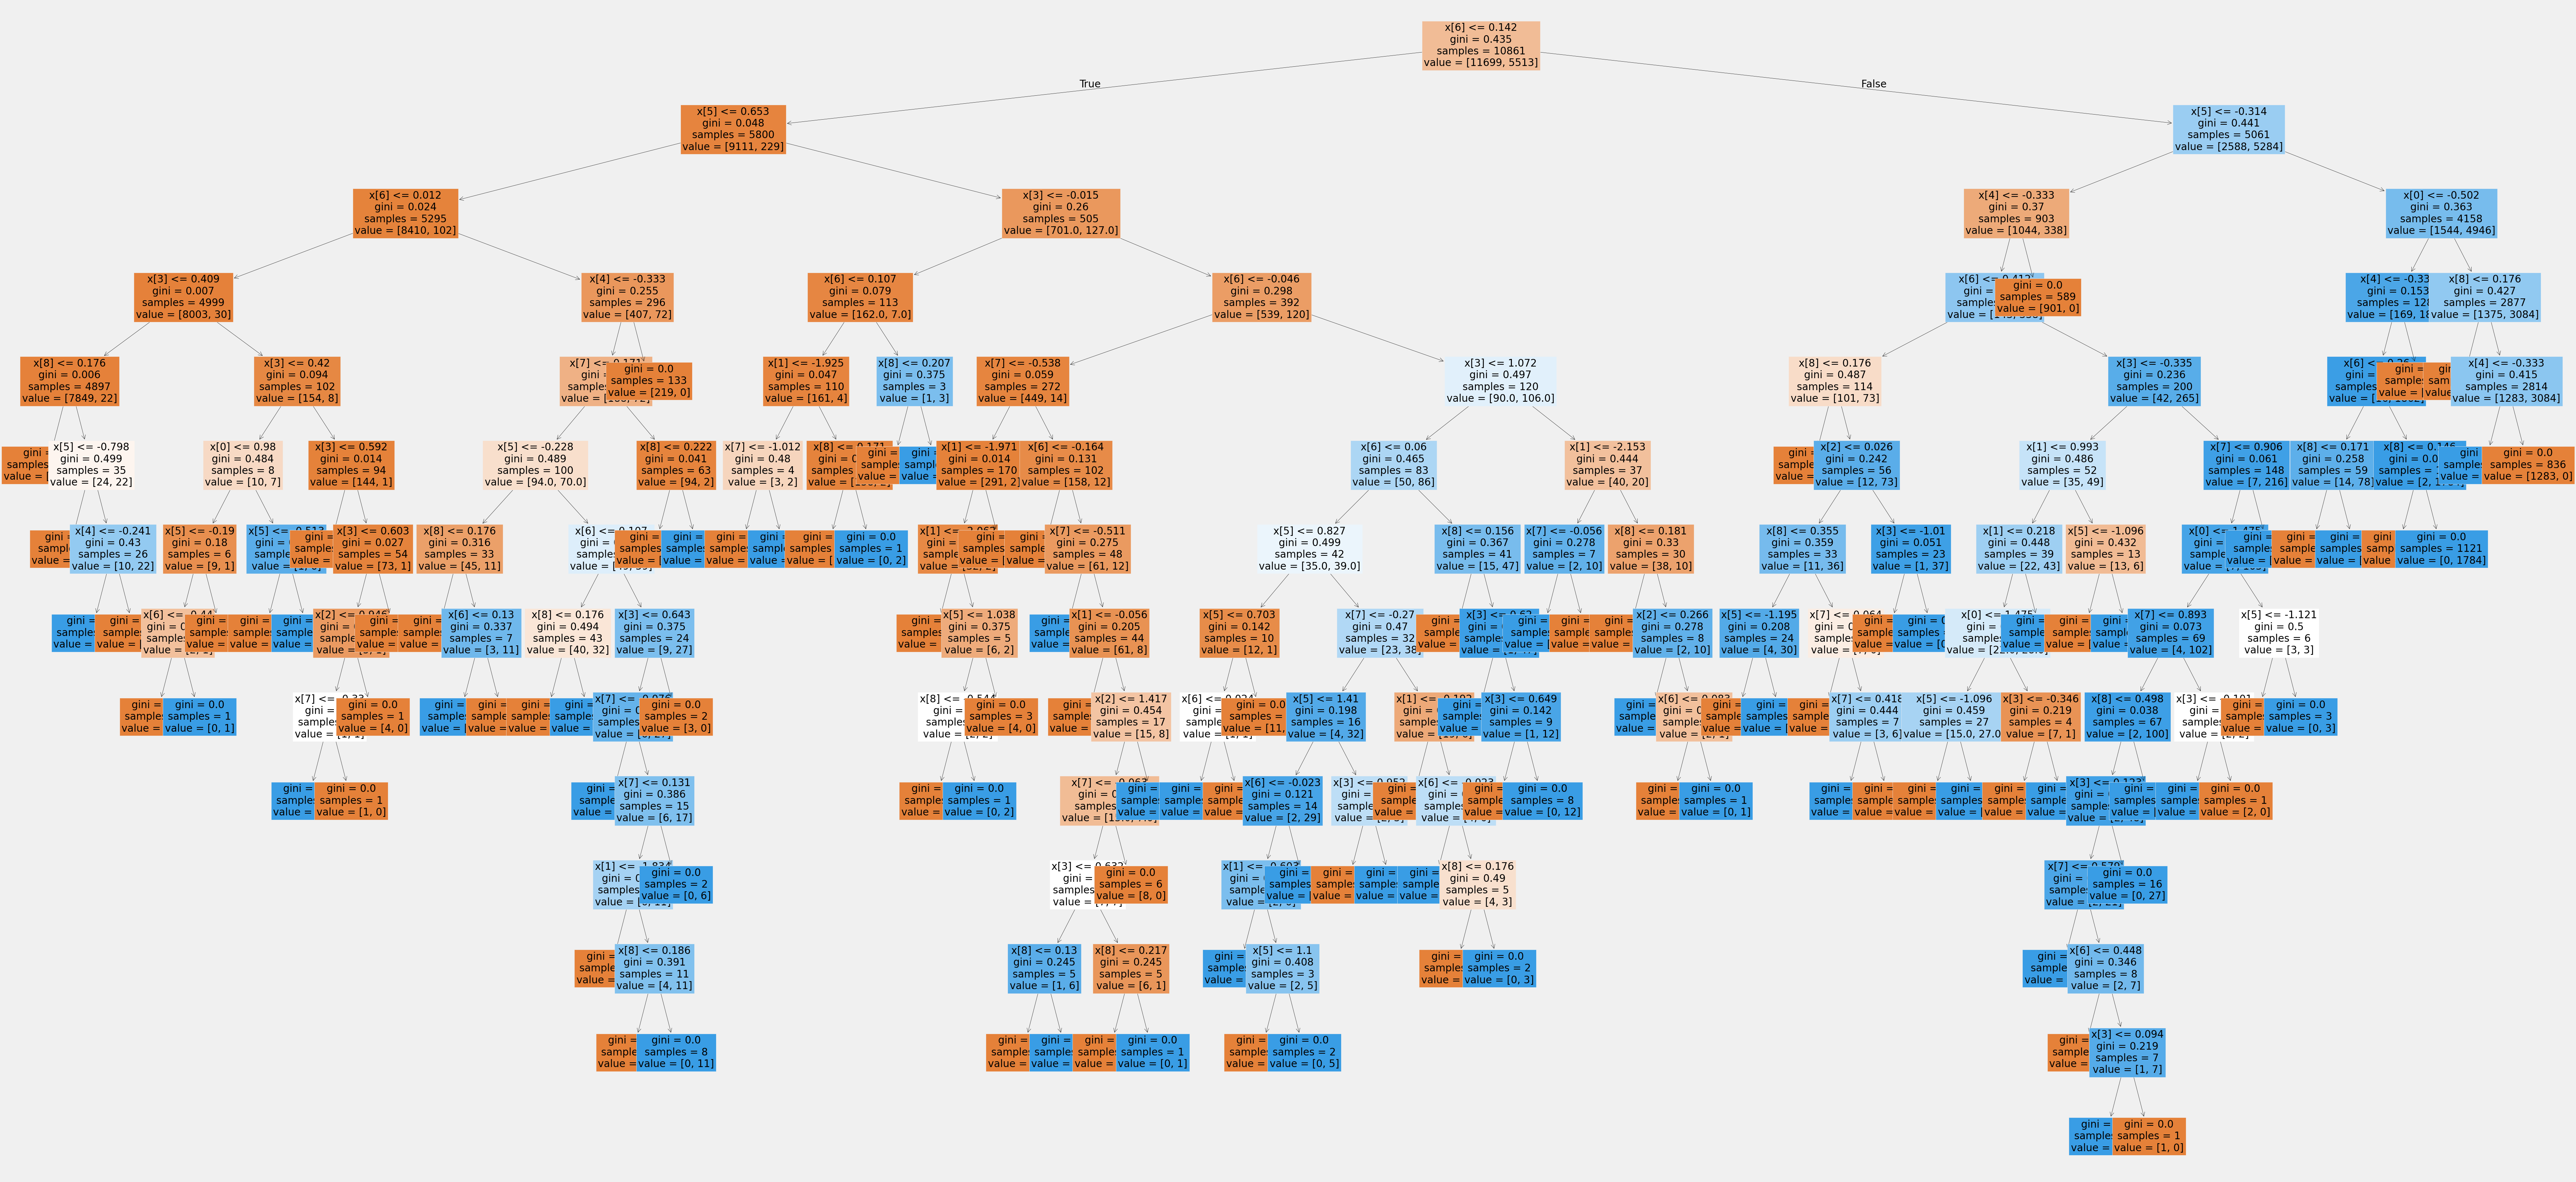

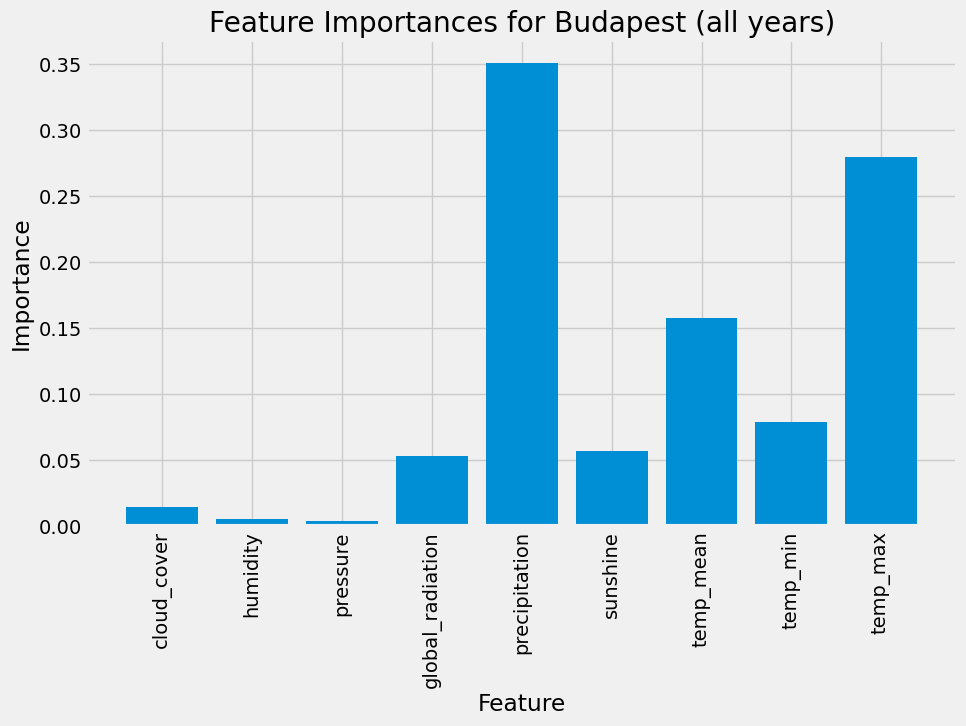

In [52]:
# Plot
plt.style.use('fivethirtyeight')
x_values = list(range(len(newarray)))

plt.figure(figsize=(10,6))
plt.bar(x_values, newarray)  # vertical by default
plt.xticks(x_values, wx_list, rotation=90)
plt.ylabel('Importance')
plt.xlabel('Feature')
plt.title('Feature Importances for Budapest (all years)')

# Save
os.makedirs(os.path.join(path, 'Visualizations'), exist_ok=True)
plt.savefig(os.path.join(path, 'Visualizations', 'Budapest_feature_importances.png'), bbox_inches='tight')
plt.show()